Autor יהוה y Kaoru Aguilera Katayama

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


Saving ghost-message (3).mp4 to ghost-message (3).mp4
Video: 1280x720, 187 frames


## Máscara recuperada desde el movimiento

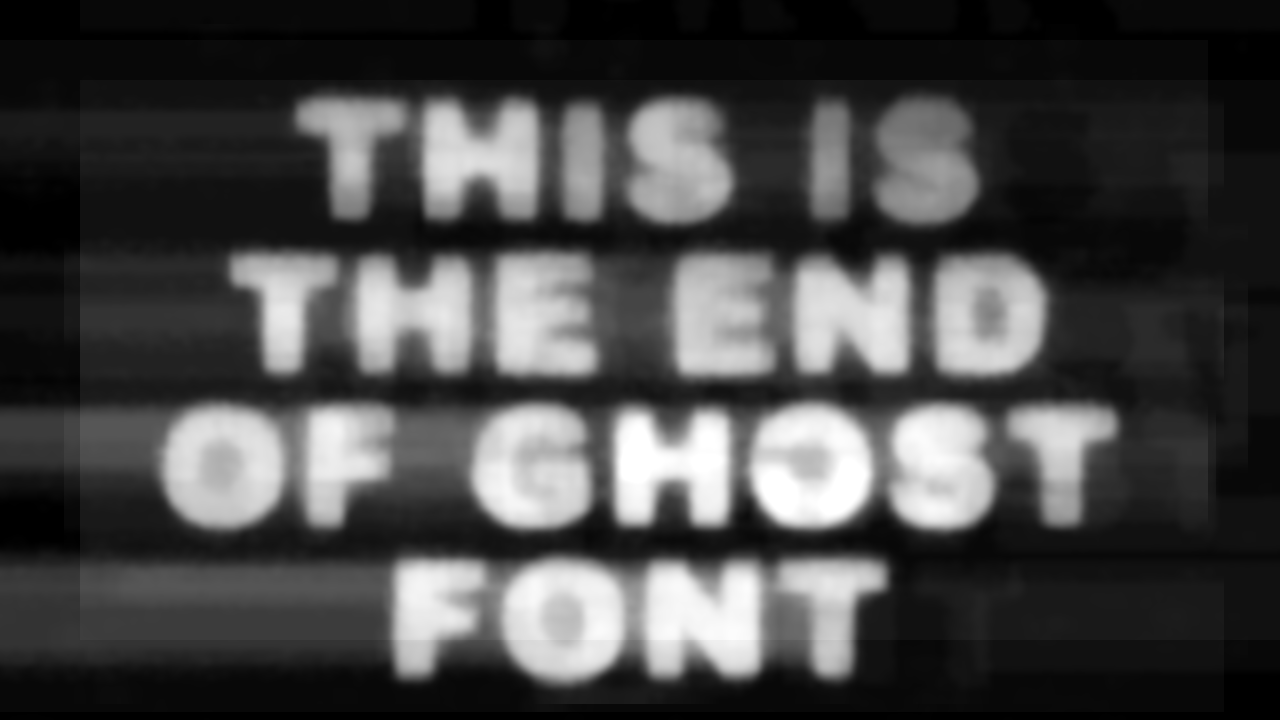


Archivo guardado: ghost_font_movimiento_decodificado.png


## Texto detectado

MT EE
THE END
OF GHOST
FONT


In [ ]:
# === DECODIFICADOR DETERMINISTA PARA VIDEOS DE https://www.mixfont.com/ghost-font ===
# Una sola celda. No entrena con el video ni genera datos sintéticos.
# El OCR final es opcional: el decodificador de movimiento funciona sin él.

!apt-get -qq update && apt-get -qq install -y tesseract-ocr > /dev/null
!pip -q install pytesseract

import re, cv2, numpy as np, pytesseract
from google.colab import files
from IPython.display import display, Image, Markdown

USAR_OCR_PREENTRENADO = True  # False = solo genera la máscara revelada, sin OCR externo
cv2.setNumThreads(1)          # ejecución reproducible en CPU

# 1) Subir video
subido = files.upload()
video = next(iter(subido.keys()))

# 2) Leer los cuadros reales del video
cap = cv2.VideoCapture(video)
frames = []
while True:
    ok, frame = cap.read()
    if not ok:
        break
    frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY))
cap.release()

if len(frames) < 12:
    raise RuntimeError("El video es demasiado corto: usa al menos ~1 segundo de animación.")

H, W = frames[0].shape
print(f"Video: {W}x{H}, {len(frames)} frames")

# Ghost Font tiene un campo de ruido que baja y un campo enmascarado que sube.
# Extraemos el flujo vertical. El movimiento dominante es el fondo;
# el movimiento contrario revela el mensaje.
motor = cv2.DISOpticalFlow_create(cv2.DISOPTICAL_FLOW_PRESET_ULTRAFAST)
n_pares = min(38, len(frames) - 1)
indices = np.unique(np.linspace(0, len(frames) - 2, n_pares).astype(int))

k = max(5, int(round(min(H, W) / 34)) | 1)  # 21 px para el video original 1280x720
mapas = []

for i in indices:
    flujo_y = motor.calc(frames[i], frames[i + 1], None)[:, :, 1]
    v_fondo = float(np.median(flujo_y))
    direccion_fondo = 1.0 if v_fondo >= 0 else -1.0

    # Alto = píxel cuyo flujo va en el sentido opuesto al fondo.
    señal = np.maximum(0, direccion_fondo * (v_fondo - flujo_y))
    señal = np.clip(señal / max(abs(v_fondo), 1.0), 0, 1)
    señal = cv2.GaussianBlur(señal, (k, k), 0)
    señal = np.maximum(señal - 0.08, 0)
    mapas.append(señal.astype(np.float32))

# Ya no hacen falta los frames: liberamos memoria.
del frames

# 3) La frase se desplaza ligeramente siguiendo una oscilación.
# Alineamos cada mapa con una búsqueda exhaustiva discreta: sin azar, sin entrenamiento.
sw = 160
sh = max(45, round(sw * H / W))
sx, sy = W / sw, H / sh
R = 10
margen = R + 2
referencia = mapas[0].copy()

for _ in range(4):
    ref_peq = cv2.resize(referencia, (sw, sh), interpolation=cv2.INTER_AREA)
    centro = ref_peq[margen:-margen, margen:-margen]
    alineados = []

    for mapa in mapas:
        m_peq = cv2.resize(mapa, (sw, sh), interpolation=cv2.INTER_AREA)
        mejor_score, mejor_dx, mejor_dy = -np.inf, 0, 0

        for dy in range(-R, R + 1):
            for dx in range(-R, R + 1):
                candidato = np.roll(m_peq, (dy, dx), axis=(0, 1))
                score = float(np.sum(centro * candidato[margen:-margen, margen:-margen]))
                if score > mejor_score:
                    mejor_score, mejor_dx, mejor_dy = score, dx, dy

        matriz = np.float32([[1, 0, mejor_dx * sx], [0, 1, mejor_dy * sy]])
        alineados.append(
            cv2.warpAffine(
                mapa, matriz, (W, H),
                flags=cv2.INTER_LINEAR,
                borderMode=cv2.BORDER_CONSTANT,
                borderValue=0
            )
        )

    referencia = np.mean(alineados, axis=0).astype(np.float32)

# 4) Imagen final: máscara temporal recuperada.
alto = max(float(np.quantile(referencia, 0.995)), 1e-8)
revelado = np.clip(referencia * 255.0 / alto, 0, 255).astype(np.uint8)

salida = "ghost_font_movimiento_decodificado.png"
cv2.imwrite(salida, revelado)

display(Markdown("## Máscara recuperada desde el movimiento"))
display(Image(filename=salida))
print(f"\nArchivo guardado: {salida}")

# 5) Lectura del texto. Esto no entrena nada con tu video;
# Tesseract sí es un OCR preentrenado. Desactívalo si deseas cero modelo externo.
if USAR_OCR_PREENTRENADO:
    bruto = pytesseract.image_to_string(revelado, config="--psm 6")
    lineas = []
    for linea in bruto.upper().splitlines():
        linea = re.sub(r"[^A-Z0-9 .,!?'&-]", " ", linea)
        linea = re.sub(r"\s+", " ", linea).strip()
        if linea:
            lineas.append(linea)

    texto = "\n".join(lineas) if lineas else "[OCR incierto: revisa la máscara recuperada]"
    display(Markdown("## Texto detectado"))
    print(texto)

Este te da el texto detectado por OCR puede fallar, pero si metes esta imagen que decifro mi algoritmo a un LLM. Sabara exactamente que esta escrito

This gives you the text detected by OCR. It may make mistakes, but if you feed the image decoded by my algorithm into an LLM, it will know exactly what's written.